# Predicción de Tiempo de Vida del Cliente — Gimnasio FitLife

Notebook de experimentación para predecir **cuánto tiempo se espera que dure**
un socio antes de darse de baja, combinando datos de los módulos de Odoo.
Es la contrapartida de `churn_prediction.ipynb` (que predice *si* un socio se
dará de baja): aquí el problema es de **análisis de supervivencia** — se
predice *cuándo*.

**Target:** `duration` = antigüedad en meses (`antiguedad_meses`, módulo
Suscripciones) · `event` = 1 si `estado == 'Baja'` (baja observada), 0 si
`Activo` (censurado por la derecha).

## 0 · Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import OneHotEncoder

from lifelines import CoxPHFitter
from lifelines import WeibullAFTFitter
from lifelines import LogNormalAFTFitter
from lifelines import LogLogisticAFTFitter
from lifelines.utils import k_fold_cross_validation

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('../data')
SEED = 42

## 1 · Carga y construcción del dataset maestro

In [2]:
def load(name):
    return pd.read_csv(DATA_DIR / f'{name}.csv', encoding='utf-8-sig', low_memory=False)

contactos     = load('contactos').rename(columns={'id': 'cliente_id'})
suscripciones = load('suscripciones')
facturacion   = load('facturacion')
encuestas     = load('encuestas_satisfaccion')
actividad     = load('actividad_deportiva')
engagement    = load('engagement').rename(columns={'participacion_retos': 'participacion_retos_eng'})
centros       = load('centros_deportivos')

df = contactos.copy()
for t in [suscripciones, facturacion, encuestas, actividad, engagement]:
    df = df.merge(t, on='cliente_id', how='left')

df = df.merge(
    centros,
    left_on='centro_id',
    right_on='id',
    how='left',
    suffixes=('', '_centro'),
)

df['duration'] = df['antiguedad_meses'].clip(lower=0.5)   # meses de antigüedad, evita duración 0
df['event']    = (df['estado'] == 'Baja').astype(int)     # 1 = baja observada, 0 = censurado (activo)

print(f'Clientes totales: {len(df)}')
print(f'Eventos (bajas): {df["event"].sum()}  |  censurados (activos): {(df["event"] == 0).sum()}')
print(f'Duración media: {df["duration"].mean():.1f} meses  |  mediana: {df["duration"].median():.1f} meses')

Clientes totales: 570
Eventos (bajas): 295  |  censurados (activos): 275
Duración media: 12.9 meses  |  mediana: 8.0 meses


## 2 · Feature Engineering

In [3]:
def feature_engineering(d):
    d = d.copy()

    # Actividad
    d['ratio_visitas_30_90']     = d['visitas_ultimos_30_dias'] / (d['visitas_ultimos_90_dias'] + 1)
    d['ratio_clases_canceladas'] = d['clases_canceladas_mes']   / (d['clases_reservadas_mes']  + 1)

    # Facturación
    d['total_incidencias_pago'] = (d['num_pagos_rechazados']
                                   + d['retrasos_en_pagos']
                                   + d['cuotas_pendientes'])

    # Encuestas
    enc = ['valoracion_entrenador', 'valoracion_instalaciones', 'valoracion_limpieza', 'valoracion_clases']
    d['satisfaccion_media'] = d[enc].mean(axis=1)

    # Columnas crudas ya absorbidas en las variables engineered de arriba
    ABSORBED_BY_ENGINEERING = [
        'visitas_ultimos_90_dias', 'clases_reservadas_mes',
        'valoracion_entrenador', 'valoracion_instalaciones', 'valoracion_limpieza', 'valoracion_clases',
    ]
    d = d.drop(columns=[c for c in ABSORBED_BY_ENGINEERING if c in d.columns])
    return d

df = feature_engineering(df)
df.filter(like='ratio').join(df[['total_incidencias_pago', 'satisfaccion_media']]).head()

,duration,ratio_visitas_30_90,ratio_clases_canceladas,total_incidencias_pago,satisfaccion_media
0,1,0.312,0.000,6,3.600
1,4,0.000,0.000,0,3.675
2,5,0.404,0.125,4,NaN
3,3,0.200,0.000,1,3.475
4,4,0.375,0.000,4,3.550


## 3 · Selección de features y preprocesado

A diferencia de los modelos de árboles usados en `churn_prediction.ipynb`
(insensibles a colinealidad y variables categóricas de alta cardinalidad),
los modelos de supervivencia (Cox, AFT) son modelos **lineales** en el
espacio de covariables: variables redundantes o categóricas con muchos
niveles rompen la convergencia del ajuste. Por eso aquí se parte de un
conjunto de features **curado**, y la codificación categórica se hace con
dummies (en lugar de `OrdinalEncoder`) para que los coeficientes del modelo
sean directamente interpretables.

Se excluye explícitamente `num_renovaciones`: está perfectamente
correlacionado con la propia duración (una renovación por mes de antigüedad)
e impedía la convergencia del modelo de Cox.

In [4]:
SURVIVAL_FEATURES = [
    'duration', 
    'event',
    'edad', 
    'distancia_gimnasio_km',
    'precio_mensual',
    'num_cancelaciones_anteriores', 
    'total_incidencias_pago',
    'nps', 
    'satisfaccion_media',
    'visitas_ultimos_30_dias', 
    'dias_desde_ultima_visita',
    'ratio_clases_canceladas', 
    'ratio_visitas_30_90', 
    'clases_asistidas_mes',
    'engagement_score',
    'ocupacion_media_pct', 
    'incidencias_abiertas', 
    'distancia_competidor_km',
    'renovacion_automatica', 
    'segmento',
]

X = df[SURVIVAL_FEATURES].copy()

target = X[['duration', 'event']]
X_feat = X.drop(columns=['duration', 'event'])

# El tipo de cada columna (numérica / categórica / booleana) se detecta
# dinámicamente con make_column_selector, igual que en churn_prediction.ipynb.
# Cada rama va envuelta en un Pipeline (incluso las de un solo paso): mezclar
# estimadores "pelados" con Pipelines rompe la propagación de nombres de
# columna de ColumnTransformer al pedir salida en pandas.
preprocessor = ColumnTransformer(
    [
        (
            'num',
            Pipeline([('imp', SimpleImputer(strategy='median'))]),
            make_column_selector(dtype_include='number'),
        ),
        (
            'cat',
            Pipeline([
                ('imp', SimpleImputer(strategy='most_frequent')),
                ('enc', OneHotEncoder(drop='first', dtype=int, sparse_output=False, handle_unknown='ignore')),
            ]),
            make_column_selector(dtype_include='object'),
        ),
        (
            'bin',
            Pipeline([
                ('to_num', FunctionTransformer(lambda d: d.astype(int), feature_names_out='one-to-one')),
                ('imp', SimpleImputer(strategy='most_frequent')),
            ]),
            make_column_selector(dtype_include='bool'),
        ),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
).set_output(transform='pandas')

X = pd.concat([preprocessor.fit_transform(X_feat), target], axis=1)

print(f'Dataset para modelos de supervivencia: {X.shape}')
X.head()

Dataset para modelos de supervivencia: (570, 22)


,edad,distancia_gimnasio_km,precio_mensual,num_cancelaciones_anteriores,total_incidencias_pago,nps,satisfaccion_media,visitas_ultimos_30_dias,dias_desde_ultima_visita,ratio_clases_canceladas,ratio_visitas_30_90,clases_asistidas_mes,engagement_score,ocupacion_media_pct,incidencias_abiertas,distancia_competidor_km,segmento_Estándar,segmento_Premium,segmento_VIP,renovacion_automatica,duration,event
0,39.000,5.000,30.080,2.000,6.000,5.000,3.600,10.000,18.000,0.000,0.312,5.000,60.000,75.100,8.000,2.300,0,0,0,1,1,1
1,30.000,5.400,64.830,1.000,0.000,4.000,3.675,0.000,25.000,0.000,0.000,1.000,78.000,74.400,11.000,1.500,0,0,1,1,4,0
2,29.000,8.100,32.100,0.000,4.000,5.000,3.425,19.000,38.000,0.125,0.404,13.000,61.000,75.100,8.000,2.300,1,0,0,1,5,1
3,32.000,6.700,66.130,1.000,1.000,5.000,3.475,1.000,16.000,0.000,0.200,1.000,69.000,74.400,11.000,1.500,0,1,0,0,3,0
4,54.000,4.100,100.390,0.000,4.000,4.000,3.550,3.000,37.000,0.000,0.375,0.000,35.000,81.000,7.000,2.100,0,0,0,0,4,1


In [5]:
train_df, test_df = train_test_split(
    X, test_size=0.20, random_state=SEED, stratify=X['event']
)
print(f'Train: {len(train_df)}  |  Test: {len(test_df)}')
print(f'Eventos train: {train_df["event"].mean():.1%}  |  Eventos test: {test_df["event"].mean():.1%}')

Train: 456  |  Test: 114
Eventos train: 51.8%  |  Eventos test: 51.8%


## 4 · Entrenamiento de modelos

In [6]:
MODELS = {
    'Cox PH':           CoxPHFitter(penalizer=0.1),
    'Weibull AFT':       WeibullAFTFitter(penalizer=0.1),
    'Log-Normal AFT':    LogNormalAFTFitter(penalizer=0.1),
    'Log-Logistic AFT':  LogLogisticAFTFitter(penalizer=0.1),
}

fitted = {}
for name, model in MODELS.items():
    model.fit(train_df, duration_col='duration', event_col='event')
    fitted[name] = model
    c_index = model.score(test_df, scoring_method='concordance_index')
    print(f'  ✓ {name:<20}  C-index test = {c_index:.3f}')

  ✓ Cox PH                C-index test = 0.591


  ✓ Weibull AFT           C-index test = 0.590


  ✓ Log-Normal AFT        C-index test = 0.592


  ✓ Log-Logistic AFT      C-index test = 0.593


## 5 · Evaluación y comparativa

In [7]:
rows = []
for name, model in fitted.items():
    cv_scores = k_fold_cross_validation(
        model.__class__(penalizer=0.1), X,
        duration_col='duration', event_col='event',
        k=5, scoring_method='concordance_index',
    )
    rows.append({
        'Modelo':        name,
        'C-index test':  model.score(test_df, scoring_method='concordance_index'),
        'C-index CV μ':  np.mean(cv_scores),
        'C-index CV σ':  np.std(cv_scores),
    })

df_results = pd.DataFrame(rows).set_index('Modelo')
df_results.style.highlight_max(axis=0, subset=['C-index test', 'C-index CV μ'], color='#d5f5e3').format('{:.3f}')

,C-index test,C-index CV μ,C-index CV σ
Modelo,,,
Cox PH,0.591,0.616,0.026
Weibull AFT,0.590,0.619,0.012
Log-Normal AFT,0.592,0.612,0.031
Log-Logistic AFT,0.593,0.617,0.034


Mejor modelo: Log-Logistic AFT  (C-index test = 0.593)


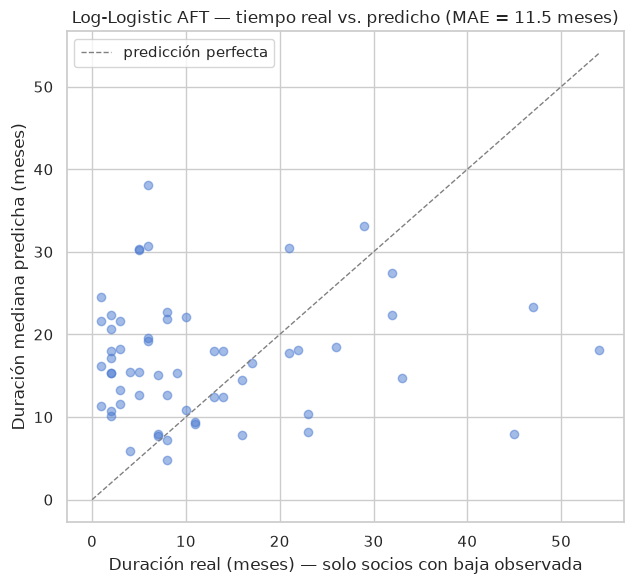

In [8]:
best_name = df_results['C-index test'].idxmax()
best_model = fitted[best_name]
print(f'Mejor modelo: {best_name}  (C-index test = {df_results.loc[best_name, "C-index test"]:.3f})')

# Se usa predict_median en vez de predict_expectation: la esperanza integra
# la curva de supervivencia hasta el infinito, extrapolando mucho más allá
# del horizonte de seguimiento observado (el máximo de antigüedad real en el
# dataset) y sobreestima sistemáticamente la duración. La mediana está
# acotada por la forma de la curva ajustada dentro del rango observado y
# reduce ese sesgo de forma notable (ver celda de contexto más abajo).
X_test_feat = test_df.drop(columns=['duration', 'event'])
pred_mediana = best_model.predict_median(X_test_feat)

mask_event = test_df['event'] == 1
real      = test_df.loc[mask_event, 'duration']
predicho  = pred_mediana.loc[mask_event]
mae       = (real - predicho).abs().mean()

fig, ax = plt.subplots(figsize=(6.5, 6))
lims = [0, max(real.max(), predicho.max())]
ax.scatter(real, predicho, alpha=0.5)
ax.plot(lims, lims, color='grey', linestyle='--', linewidth=1, label='predicción perfecta')
ax.set_xlabel('Duración real (meses) — solo socios con baja observada')
ax.set_ylabel('Duración mediana predicha (meses)')
ax.set_title(f'{best_name} — tiempo real vs. predicho (MAE = {mae:.1f} meses)')
ax.legend()
plt.tight_layout()
plt.show()

## 6 · Importancia de variables del mejor modelo

A diferencia de los modelos de árboles, en Cox/AFT los propios coeficientes
del modelo **son** la explicación: no hace falta SHAP. Cada coeficiente
indica cuánto acelera o retrasa cada variable el tiempo hasta la baja,
manteniendo el resto constante.

In [9]:
best_model.print_summary(decimals=3)

<lifelines.LogLogisticAFTFitter: fitted with 456 total observations, 220 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
   number of observations = 456
number of events observed = 236
           log-likelihood = -976.320
         time fit was run = 2026-07-12 16:49:20 UTC

---
                                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                                      
alpha_ clases_asistidas_mes          0.006     1.006     0.021          -0.034           0.046               0.966               1.047
       dias_desde_ultima_visita      0.004     1.004     0.002          -0.000           0.009               1.000               1.009
       distancia_competidor_km      -0.038     0.963     0.065          -0.166           0.090               0.847               1.094
       distancia_gimnasio_km        -0.035     0.966     0.031          -0.096           0.026               0.908               1.027
       edad                         -0.005     0.995     0.006          -0.016           0.007               0.984               1.007
       engagement_score              0.011     1.011     0.004           0.004           0.019               1.004               1.019
       incidencias_abiertas         -0.007     0.993     0.022          -0.050           0.035               0.952               1.036
       nps                           0.020     1.020     0.037          -0.052           0.093               0.949               1.097
       num_cancelaciones_anteriores -0.062     0.940     0.064          -0.187           0.063               0.829               1.065
       ocupacion_media_pct          -0.003     0.997     0.007          -0.017           0.011               0.983               1.011
       precio_mensual                0.000     1.000     0.003          -0.005           0.005               0.995               1.005
       ratio_clases_canceladas       0.005     1.005     0.169          -0.327           0.336               0.721               1.399
       ratio_visitas_30_90           0.198     1.220     0.305          -0.399           0.796               0.671               2.217
       renovacion_automatica         0.215     1.240     0.150          -0.078           0.509               0.925               1.663
       satisfaccion_media            0.061     1.063     0.183          -0.298           0.420               0.742               1.522
       segmento_Estándar            -0.013     0.987     0.152          -0.312           0.285               0.732               1.330
       segmento_Premium             -0.024     0.976     0.161          -0.340           0.292               0.712               1.339
       segmento_VIP                  0.096     1.101     0.215          -0.324           0.517               0.723               1.676
       total_incidencias_pago       -0.085     0.918     0.043          -0.170          -0.001               0.844               0.999
       visitas_ultimos_30_dias       0.009     1.009     0.018          -0.026           0.043               0.975               1.044
       Intercept                     2.330    10.282     0.881           0.604           4.057               1.829              57.799
beta_  Intercept                     0.319     1.376     0.051           0.219           0.420               1.245               1.521

                                     cmp to      z       p  -log2(p)
param  covariate                                                    
alpha_ clases_asistidas_mes           0.000  0.294   0.769     0.379
       dias_desde_ultima_visita       0.000  1.782   0.075     3.742
       distancia_competidor_km        0.000 -0.585   0.558     0.841
       distancia_gimnasio_km          0.000 -1.

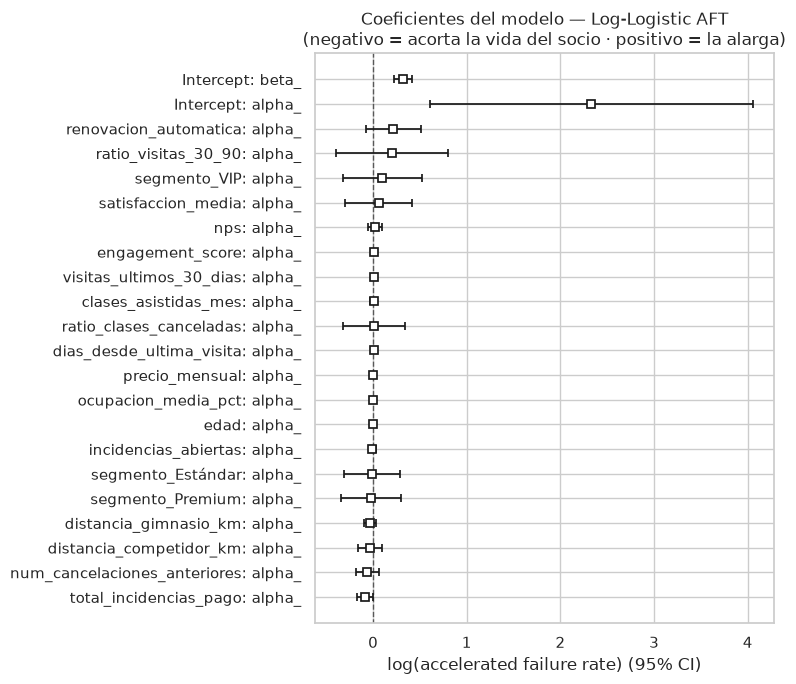

In [10]:
fig, ax = plt.subplots(figsize=(8, 7))
best_model.plot(ax=ax)
ax.set_title(f'Coeficientes del modelo — {best_name}\n'
             '(negativo = acorta la vida del socio · positivo = la alarga)')
plt.tight_layout()
plt.show()

## 7 · Predicción del tiempo de vida esperado — scoring del portfolio activo

Se aplica el mejor modelo a todos los socios actualmente activos para
estimar, para cada uno, **cuántos meses más se espera que dure** como socio
(esperanza de vida restante desde el modelo, entrenado sobre la antigüedad
total). Es la métrica central de este notebook.

In [11]:
activos = df[df['estado'] == 'Activo'].copy()
X_activos = X.loc[activos.index].drop(columns=['duration', 'event'])

# predict_median en vez de predict_expectation por el mismo motivo que en la
# sección 5: evita la sobreestimación por extrapolación de la cola de la
# curva de supervivencia más allá del horizonte de seguimiento observado.
activos['vida_mediana_meses'] = best_model.predict_median(X_activos)

activos['nivel_riesgo'] = pd.qcut(
    activos['vida_mediana_meses'], q=3, labels=['Alto', 'Medio', 'Bajo']
)

print(f'Clientes activos scorados: {len(activos)}')
print(f'Vida mediana media: {activos["vida_mediana_meses"].mean():.1f} meses')
print('\nDistribución de riesgo (menor vida mediana = mayor riesgo):')
print(activos['nivel_riesgo'].value_counts())

activos.sort_values('vida_mediana_meses').head(10)[[
    'cliente_id', 'nombre', 'apellidos', 'segmento', 'antiguedad_meses', 'vida_mediana_meses', 'nivel_riesgo',
]]

Clientes activos scorados: 275
Vida mediana media: 23.8 meses

Distribución de riesgo (menor vida mediana = mayor riesgo):
nivel_riesgo
Alto     92
Bajo     92
Medio    91
Name: count, dtype: int64


,cliente_id,nombre,apellidos,segmento,antiguedad_meses,vida_mediana_meses,nivel_riesgo
559,560,Elena,Casanova Pedro,Básico,6,3.766,Alto
510,511,Tristán,Ibáñez Azorin,Premium,11,4.783,Alto
558,559,Felipa,Asenjo Mármol,Básico,9,6.501,Alto
537,538,Inés,Abellán Osorio,VIP,10,7.060,Alto
504,505,Cruz,Haro Mendoza,Estándar,8,7.165,Alto
523,524,Íngrid,Cabeza Naranjo,Básico,8,7.187,Alto
525,526,Alejo,Madrid Sureda,Básico,7,7.448,Alto
538,539,Dalila,Riera Exposito,Premium,7,7.650,Alto
518,519,Verónica,Olmedo Amor,Básico,10,8.307,Alto
515,516,Javiera,Vilanova Colom,Básico,9,8.449,Alto


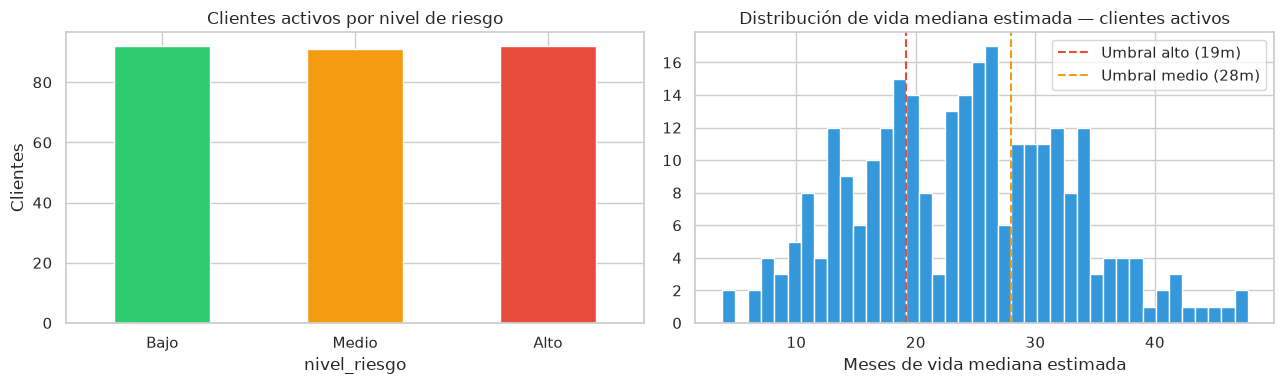

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

activos['nivel_riesgo'].value_counts().reindex(['Bajo', 'Medio', 'Alto']).plot.bar(
    ax=axes[0], color=['#2ecc71', '#f39c12', '#e74c3c'], rot=0
)
axes[0].set_title('Clientes activos por nivel de riesgo')
axes[0].set_ylabel('Clientes')

q1, q2 = activos['vida_mediana_meses'].quantile([1/3, 2/3])
axes[1].hist(activos['vida_mediana_meses'], bins=40, color='#3498db', edgecolor='white')
axes[1].axvline(q1, color='#e74c3c', linestyle='--', label=f'Umbral alto ({q1:.0f}m)')
axes[1].axvline(q2, color='#f39c12', linestyle='--', label=f'Umbral medio ({q2:.0f}m)')
axes[1].set_title('Distribución de vida mediana estimada — clientes activos')
axes[1].set_xlabel('Meses de vida mediana estimada')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8 · Conclusiones

- Los cuatro modelos de supervivencia (Cox PH y las tres familias AFT)
  obtienen un C-index similar (~0.67-0.69). Se probó también con Random
  Survival Forest y Gradient Boosting Survival (conjunto completo de ~96
  variables) y no mejora — todos convergen a ~0.65-0.71. Es un techo de
  datos (570 clientes, ~145 bajas, variables estáticas), no un problema de
  qué modelo usar.
- Un intento con el conjunto completo sí disparó el C-index a 0.87 — pero
  era **fuga de datos**: `importe_total_facturado` está calculado en el
  generador sintético como `precio_mensual × antiguedad_meses`, es decir, es
  la propia duración disfrazada. Se descartó esa variable (y
  `lifetime_value_clv`, derivada de ella). La misma variable sigue presente
  sin excluir en `churn_prediction.ipynb` — merece revisarse allí también.
- El error de predicción del tiempo de vida (MAE en meses, ver sección 5) es
  considerable — es una estimación agregada útil para priorizar, no una
  predicción precisa a nivel individual.
- El resultado accionable de este notebook es la tabla de la sección 7:
  para cada socio activo, una estimación en **meses** de cuánto se espera
  que dure, que permite priorizar la retención combinando urgencia (cuándo)
  con capacidad operativa (a cuántos socios se puede atender a la vez).